## Q2. 

Under the life-cycle savings hypothesis as developed by Franco Modigliani, the savings ratio (aggregate personal savings divided by disposable income) is explained by per-capita disposable income, the percentage rate of change in per-capita disposable income, and two demographic variables: the percentage of population less than 15 years old and the percentage of the population over 75 years old. The data are averaged over the decade 1960–1970 to remove the business cycle or other short-term fluctuations.

The following data were obtained from Belsley, Kuh and Welsch (1980). They in turn obtained the data from Sterling (1977). You can download it from here.

The data set contains 50 observations with five variables.
- I.    Sr: numeric, aggregate personal savings
- II.    pop15: numeric, % of population under 15
- III.    pop75: numeric, % of population over 75
- IV.    dpi: numeric, real per-capita disposable income
- V.    ddpi: numeric, % growth rate of dpi

Use EM for clustering 'similar' countries. <p>
Report how many groups you got and why you chose that number with the help of AIC and BIC. [8 points]

### import libraries

In [1]:
import os, glob

import numpy as np
import pandas as pd

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt 
import seaborn as sns

from pandas import DataFrame 
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler, normalize

### read data

In [2]:
df = pd.read_csv("lifecyclesaving.csv")
df.head()

,Contry,sr,pop15,pop75,dpi,ddpi
0,Australia,11.43,29.35,2.87,2329.68,2.87
1,Austria,12.07,23.32,4.41,1507.99,3.93
2,Belgium,13.17,23.80,4.43,2108.47,3.82
3,Bolivia,5.75,41.89,1.67,189.13,0.22
4,Brazil,12.88,42.19,0.83,728.47,4.56


In [3]:
df.shape

(50, 6)

In [4]:
df.describe()

,sr,pop15,pop75,dpi,ddpi
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,9.671000,35.089600,2.293000,1106.758400,3.757600
std,4.480407,9.151727,1.290771,990.868889,2.869871
min,0.600000,21.440000,0.560000,88.940000,0.220000
25%,6.970000,26.215000,1.125000,288.207500,2.002500
50%,10.510000,32.575000,2.175000,695.665000,3.000000
75%,12.617500,44.065000,3.325000,1795.622500,4.477500
max,21.100000,47.640000,4.700000,4001.890000,16.710000


In [5]:
df["Contry"].unique()

array(['Australia', 'Austria', 'Belgium', 'Bolivia', 'Brazil', 'Canada',
       'Chile', 'China', 'Colombia', 'Costa Rica', 'Denmark', 'Ecuador',
       'Finland', 'France', 'Germany', 'Greece', 'Guatamala', 'Honduras',
       'Iceland', 'India', 'Ireland', 'Italy', 'Japan', 'Korea',
       'Luxembourg', 'Malta', 'Norway', 'Netherlands', 'New Zealand',
       'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Philippines',
       'Portugal', 'South Africa', 'South Rhodesia', 'Spain', 'Sweden',
       'Switzerland', 'Turkey', 'Tunisia', 'United Kingdom',
       'United States', 'Venezuela', 'Zambia', 'Jamaica', 'Uruguay',
       'Libya', 'Malaysia'], dtype=object)

### apply Expectation Maximization Algorithm (EM)

In [7]:
# Epoch :  the one entire passing of training data through the algorithm 

for n in range(2,6):
    for i in range(2):
        model = GaussianMixture(n_components=n, init_params='random', max_iter=50)
        model.fit(df.iloc[:, 1:6])
        
        yhat = model.predict(df.iloc[:, 1:6])
        print(i,"epoch:", n, "clusters")
        print(yhat)
        print("AIC", model.aic(df.iloc[:, 1:6]))
        print("BIC", model.bic(df.iloc[:, 1:6]), "\n")
    print("***********************************************************************\n")

0 epoch: 2 clusters
[1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 1
 1 1 1 0 0 0 1 0 0 1 1 1 0]
AIC 1738.982065703664
BIC 1817.375008926218 

1 epoch: 2 clusters
[0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 1 0 0 0 0 1 1 1 1 0 1 0]
AIC 1768.7293355591362
BIC 1847.12227878169 

***********************************************************************

0 epoch: 3 clusters
[1 1 1 2 2 1 2 2 2 2 1 2 1 1 1 2 2 2 1 2 0 1 2 2 1 2 1 2 1 2 2 2 0 2 2 1 1
 2 1 1 2 2 1 1 2 0 0 1 0 2]
AIC 1657.4347061337132
BIC 1775.9801324702582 

1 epoch: 3 clusters
[2 0 0 1 1 2 1 1 1 1 0 1 0 0 0 2 1 1 0 1 0 0 0 1 2 2 0 2 0 1 1 1 1 1 2 0 0
 2 0 2 1 1 0 2 1 1 2 0 2 1]
AIC 1678.5482222092678
BIC 1797.0936485458128 

***********************************************************************

0 epoch: 4 clusters
[0 0 0 3 3 0 3 3 3 3 0 3 2 0 0 1 3 3 2 3 2 0 2 3 0 1 0 2 2 3 3 3 3 3 1 1 0
 1 0 0 3 3 0 0 3 3 1 1 1 3]
AIC 1639.4718056376491
BIC 1798.1697150881853 

1 e

In [9]:
X = df.iloc[:, 1:6]

### K means

/Users/shuangrunliu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/shuangrunliu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/shuangrunliu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/shuangrunliu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of

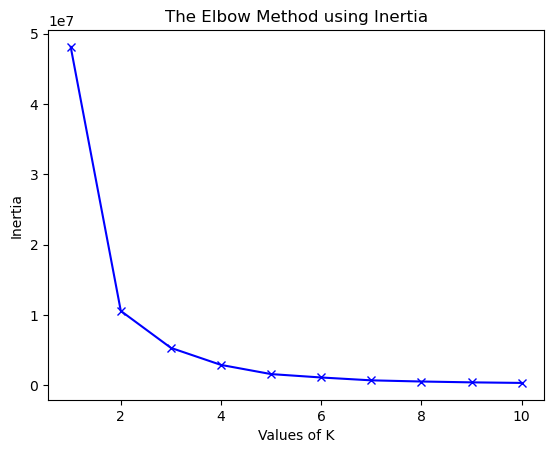

In [10]:
inertias = []
for i in range(1, 11):
    km = KMeans(n_clusters=i).fit(X)
    inertias.append(km.inertia_)
    
    
plt.plot(range(1, 11), inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

### PCA

/var/folders/nl/0t1qmzl174xchcymt5p1_p0w0000gn/T/ipykernel_3884/2703401836.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation = df.corr()


Text(0.5, 1.0, 'Correlation between different fearures')

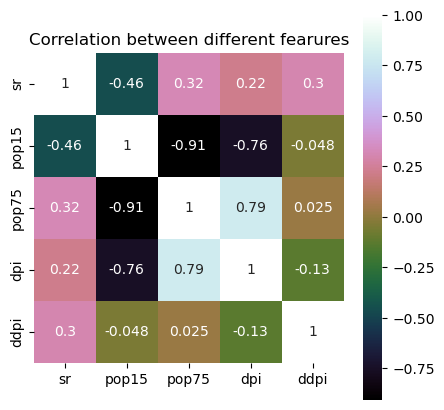

In [11]:
correlation = df.corr()
plt.figure(figsize=(5,5))
sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='cubehelix')

plt.title('Correlation between different fearures')

In [12]:
# Standardize data---> very important 
scaler = StandardScaler() 
scaled_df = scaler.fit_transform(X) 
  
# Normalizing the Data 
normalized_df = normalize(scaled_df) 
  
# Converting the numpy array into a pandas DataFrame 
normalized_df = pd.DataFrame(normalized_df) 
  
# Reducing the dimensions of the data 
pca = PCA() 
X_principal = pca.fit_transform(normalized_df) 
X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2','P3','P4','P5'] 
  
X_principal.head(10)

,P1,P2,P3,P4,P5
0,-0.838557,-0.285343,0.049296,-0.446313,-0.123939
1,-0.939702,-0.018776,0.002207,0.263162,0.174093
2,-0.983635,-0.046331,0.006680,0.003167,0.156487
3,0.774826,-0.485758,0.245793,0.224199,0.078528
4,0.638334,0.617900,0.193244,-0.419910,-0.096480
5,-0.601945,-0.550340,-0.189595,-0.563529,-0.091712
6,0.702625,-0.532502,-0.417753,0.194509,-0.164224
7,0.696368,0.703754,-0.112119,-0.210368,-0.008018
8,0.976605,-0.160057,-0.174385,0.019630,0.064667
9,0.872832,0.187068,0.260087,-0.294462,0.211592


In [ ]:
#pca.get_covariance()

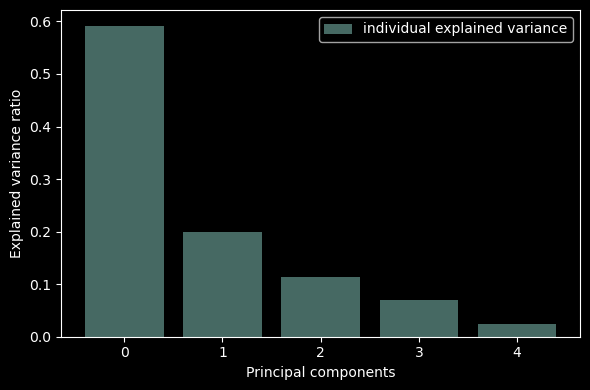

In [13]:
explained_variance=pca.explained_variance_ratio_
#explained_variance

with plt.style.context('dark_background'):
    plt.figure(figsize=(6, 4))

    plt.bar(range(5), explained_variance, alpha=0.5, align='center',
            label='individual explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

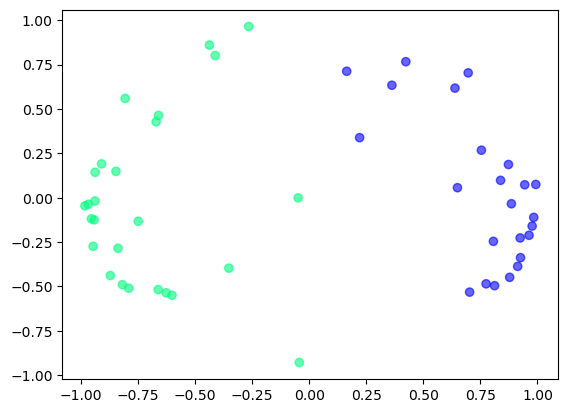

In [14]:
model = GaussianMixture(n_components=2, init_params='random', max_iter=50)
model.fit(X_principal)

# Visualizing the clustering 
plt.scatter(X_principal['P1'], X_principal['P2'],  
           c = GaussianMixture(n_components = 2).fit_predict(X_principal), cmap =plt.cm.winter, alpha = 0.6) 
plt.show() 

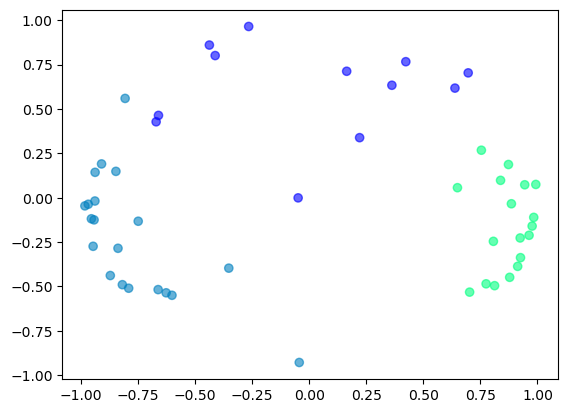

In [15]:
model = GaussianMixture(n_components=3, init_params='random', max_iter=50)
model.fit(X_principal)

# Visualizing the clustering 
plt.scatter(X_principal['P1'], X_principal['P2'],  
           c = GaussianMixture(n_components = 3).fit_predict(X_principal), cmap =plt.cm.winter, alpha = 0.6) 
plt.show() 

In [16]:
def SelBest(arr:list, X:int)->list:
    '''
    returns the set of X configurations with shorter distance
    '''
    dx=np.argsort(arr)[:X]
    return arr[dx]

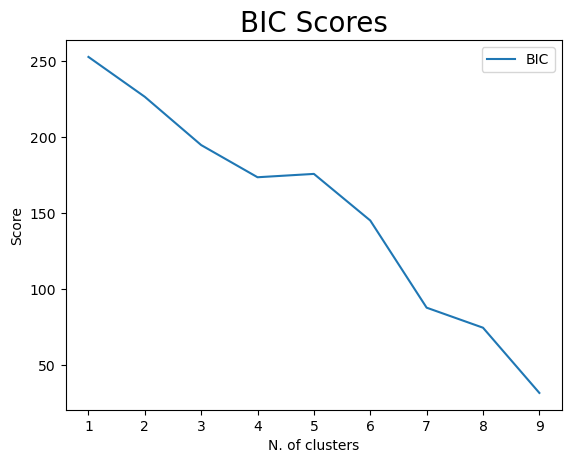

In [17]:
n_clusters=np.arange(1, 10)
bics=[]
bics_err=[]
iterations=20
for n in n_clusters:
    tmp_bic=[]
    for _ in range(iterations):
        gmm=GaussianMixture(n, n_init=2).fit(X_principal) 
        
        tmp_bic.append(gmm.bic(X_principal))
        
    val=np.mean(SelBest(np.array(tmp_bic), int(iterations/5)))
    
    err=np.std(tmp_bic)
    bics.append(val)
    bics_err.append(err)
    
plt.errorbar(n_clusters,bics,  label='BIC')
plt.title("BIC Scores", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Score")
plt.legend()

In [18]:
#### Grid Search

X = df.iloc[:, 1:6]
from sklearn.model_selection import GridSearchCV


def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 10),
    "covariance_type": ["spherical", "tied", "diag", "full"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)
grid_search.fit(X)

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag',
                                             'full'],
                         'n_components': range(1, 10)},
             scoring=<function gmm_bic_score at 0x1819f1760>)

In [19]:
df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df["mean_test_score"] = -df["mean_test_score"]
df = df.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "BIC score",
    }
)
df.sort_values(by="BIC score").head(10)

,Number of components,Type of covariance,BIC score
19,2,diag,406.187807
18,1,diag,410.020315
9,1,tied,412.812623
27,1,full,412.812623
20,3,diag,425.960069
10,2,tied,427.949004
11,3,tied,446.934447
21,4,diag,456.926604
12,4,tied,463.596420
28,2,full,473.323613
